# Code Example on PPMS_Toolkit

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from ppms_toolkit.sample import Sample
from ppms_toolkit.measurement import HeatCapacityMeasurement

from ppms_toolkit.measurement import debye_model_extended, debye_model

## Heat Capacity on Mn-PEA

In [2]:
# Initialize a sample
MnPEA = Sample(id=1,
            name = "Mn-PEA",
            mass = 7.8, 
            make_date="2025-01-12")

In [ ]:
MnPEA.add_vsm_measurements_by_folder(folder_path='test_data/VSM_TestData_4Cl_IP/')

ValueError: Mode is not contained in filename of s

In [16]:
# Load a measurement data and assign it to sample 1
Mn_PEA_HC = HeatCapacityMeasurement(filepath='test_data/HC_test_data.Dat',
                                    sample=MnPEA, 
                                    field_strength=1000)

In [6]:
import os

In [11]:
os.listdir('test_data/VSM_TestData_4Cl')

['MT_0P1T_FC.DAT',
 'MT_0P01T_ZFC.DAT',
 'MT_0P01T_FC.DAT',
 'MT_0P1T_ZFC.DAT',
 'MH_2P5K.DAT']

In [17]:
# Access to the list of Measurements
MnPEA.show_measurements

#### HeatCapacity Measurements List

,External field,Temp Range,instance
0,1000,2.0 ~ 302.6,"HC exp, Mn-PEA with 1000 Oe T-range 2.0 ~ 302.6"


There's no VSM measurements bind to this sample.


In [18]:
# Access to the processed pd.DataFrame of certain measurements
Mn_PEA_HC.dataframe

,Time Stamp (Seconds),Field (Oersted),Sample Temp (Kelvin),Samp HC (µJ/K),Samp HC Err (µJ/K),Samp HC/Temp (µJ/K/K)
Sample Temp (Kelvin),,,,,,
0,3.953442e+09,999.633427,1.994420,0.909666,0.002630,0.456104
1,3.953442e+09,999.669310,2.199579,1.173588,0.002645,0.533551
2,3.953442e+09,999.645383,2.425263,1.529208,0.003681,0.630533
3,3.953442e+09,999.513853,2.673384,2.009654,0.004339,0.751726
4,3.953442e+09,999.573647,2.945506,2.601245,0.005344,0.883123
...,...,...,...,...,...,...
155,3.953278e+09,1000.034100,258.597710,7473.481000,20.690000,28.900028
156,3.953268e+09,999.998230,279.693800,8046.697200,18.560000,28.769666
157,3.953276e+09,999.908570,279.716630,8022.202300,16.790000,28.679747


In [19]:
# Save a certain sample with all its measurements and metadata to a pickle file.
MnPEA.save()

In [20]:
# Load a Pickel file, later.
MnPEA = Sample.load('Mn-PEA(2025-01-12).pkl')

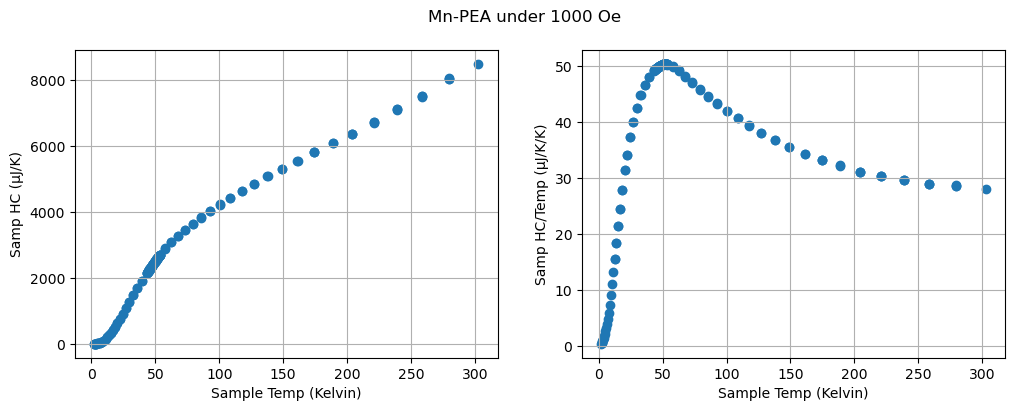

In [21]:
# plot the HC Data.
# The plot function returns the fig and ax object,
# so it's easy to manipulate and modify.
fig ,ax = Mn_PEA_HC.plot();

/Users/ryunosuke/Documents/Research/PPMS/PPMS_ToolKit/src/ppms_toolkit/measurement/utils.py:55: RuntimeWarning: overflow encountered in scalar power
  return np.where(denom == 0, 0, x**4 * ex / denom**2)


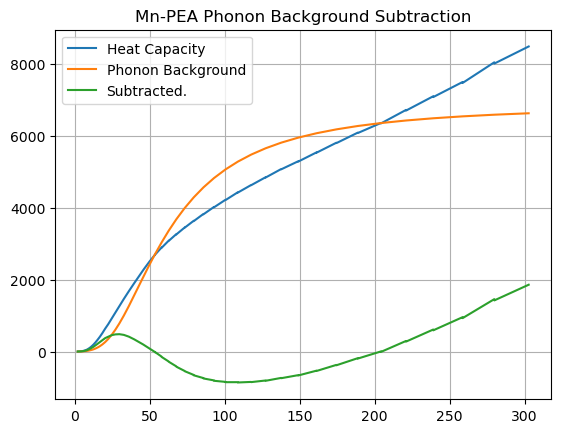

In [22]:
# Fit with default Debye Model, no bounding, no range.
T, subtracted_HC, fig, ax, params = Mn_PEA_HC.background_subtraction();

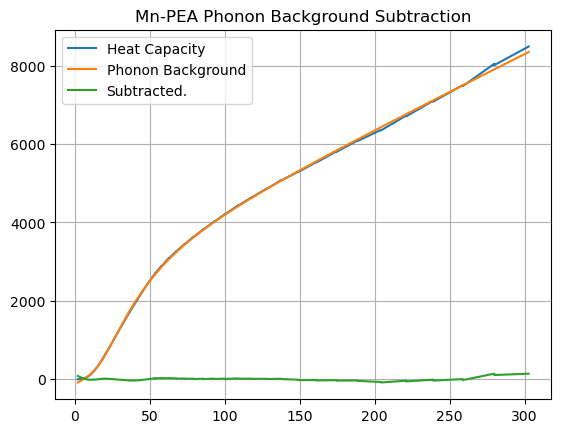

In [23]:
# Surely, you can fit with you own model function, with certain range and bounds to the fitting parameters.
fig, ax, *_  = Mn_PEA_HC.background_subtraction(model=debye_model_extended,
                                                                     mask_func=lambda T: (T>5) & (T<300),
                                                                     bounds=([1, 0.0001,-np.inf,-np.inf], 
                                                                             [500, 100,np.inf,np.inf]))

## VSM on 4Cl-Mn-BA

In [24]:
from ppms_toolkit.measurement import VSMMeasurement

In [25]:
Cl4MnBA = Sample(name='4Cl-Mn-BA',
                  mass=1.88, 
                  make_date='2025-05-02')

In [28]:
m1 = VSMMeasurement(filepath='test_data/VSM_TestData_4CL/MT_0P1T_FC.DAT',
                    sample_orientation='In Plane', 
                    mode='MT',
                    sample = Cl4MnBA)

m2 = VSMMeasurement(filepath='test_data/VSM_TestData_4CL/MT_0P1T_ZFC.DAT',
                    sample_orientation='In Plane', 
                    mode='MT',
                    sample = Cl4MnBA)

m3 = VSMMeasurement(filepath='test_data/VSM_TestData_4CL/MH_2P5K.DAT', 
                    sample_orientation='In Plane', 
                    mode='MH', 
                    sample=Cl4MnBA)

The Measurment [MT exp on 4Cl-Mn-BA with In Plane orientation at 1000Oe] 
is already exist in sample [id: None, 4Cl-Mn-BA, 1.88mg, made in 2025-05-02.] 


In [29]:
Cl4MnBA.show_measurements

There's no HC measurements bind to this sample.


#### VSM Measurements List

,mode,orientation,const temp,const field,instance
0,MT,In Plane,NaN,1000.0,MT exp on 4Cl-Mn-BA with In Plane orientation ...
1,MT,In Plane,NaN,1000.0,MT exp on 4Cl-Mn-BA with In Plane orientation ...
2,MH,In Plane,2.5,NaN,MH exp on 4Cl-Mn-BA with In Plane orientation ...


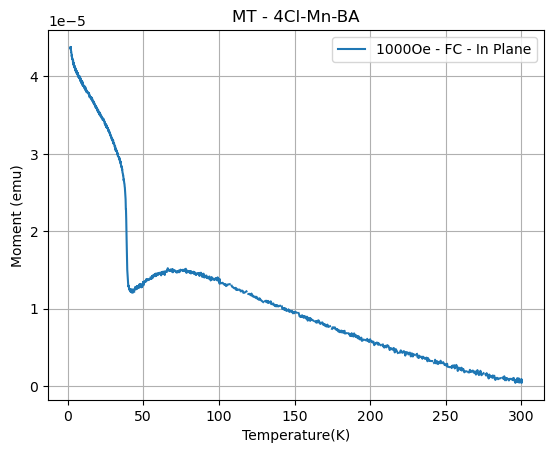

In [30]:
m1.plot();

<Axes: title={'center': 'MT - 4Cl-Mn-BA'}, xlabel='Temperature(K)', ylabel='Moment (emu)'>

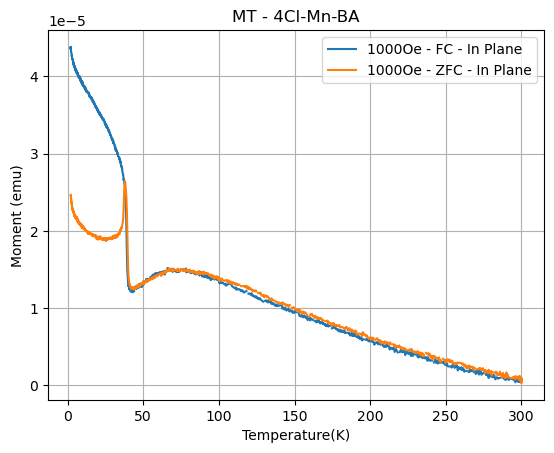

In [33]:
fig, ax = plt.subplots() 
m1.plot(ax=ax)
m2.plot(ax=ax)

In [ ]:
Cl4MnBA.save()

# Speed UP

In [ ]:
# Time to process a Heat Capacity Dataset
%timeit Mn_PEA_HC.process_data(Mn_PEA_HC.raw_dataframe)

912 μs ± 14 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [ ]:
# Time to process a M-T dataset
%timeit m3.process_data(m3.raw_dataframe)

7.22 ms ± 1.04 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
# Time to process a Hysterisis dataset
%timeit m1.process_data(m1.raw_dataframe)

1.11 ms ± 15 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [ ]:
%prun -q -D profile.prof m1.process_data(m1.raw_dataframe)
!snakeviz profile.prof

 
*** Profile stats marshalled to file 'profile.prof'.
snakeviz web server started on 127.0.0.1:8080; enter Ctrl-C to exit
http://127.0.0.1:8080/snakeviz/%2FUsers%2Fryunosuke%2FDocuments%2FResearch%2FPPMS%2FPPMS_ToolKit%2Fexamples%2Fprofile.prof
^C


In [ ]:
%lprun -f Mn_PEA_HC.background_substraction Mn_PEA_HC.background_subtraction(m1.dataframe)
!snakeviz profile.prof

UsageError: Line magic function `%lprun` not found.
